In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test  = y_test .flatten()

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
x_train.shape, x_test.shape


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


((50000, 32, 32, 3), (10000, 32, 32, 3))

In [2]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])


In [3]:
def make_cnn():
    inputs = layers.Input(shape=(32,32,3))
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = make_cnn()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
es = EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)


history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[es, rlr],
    verbose=1
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 158ms/step - accuracy: 0.2225 - loss: 2.0303 - val_accuracy: 0.3294 - val_loss: 1.7596 - learning_rate: 0.0010
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 157ms/step - accuracy: 0.3821 - loss: 1.6509 - val_accuracy: 0.4040 - val_loss: 1.6692 - learning_rate: 0.0010
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 158ms/step - accuracy: 0.4324 - loss: 1.5252 - val_accuracy: 0.4748 - val_loss: 1.4787 - learning_rate: 0.0010
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 109s 154ms/step - accuracy: 0.4698 - loss: 1.4219 - val_accuracy: 0.4978 - val_loss: 1.3705 - learning_rate: 0.0010
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 154ms/step - accuracy: 0.5039 - loss: 1.3678 - val_accuracy: 0.5422 - val_loss: 1.2522 - learning_rate: 0.0010
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.5280 - loss: 1.3047 - val_accuracy: 0.5434 - val_loss: 1.2795 - learning_rate: 0.0010
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 156ms/step - accura

In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")


Test accuracy: 0.619


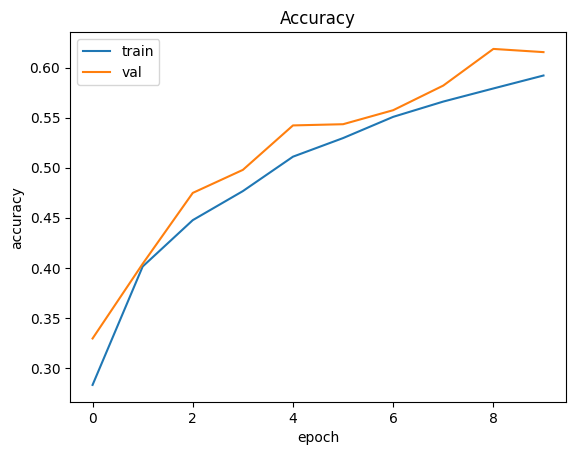

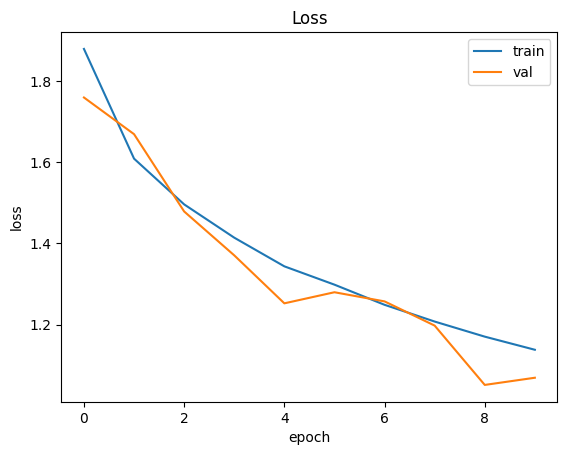

In [6]:
plt.figure()
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss")
plt.show()


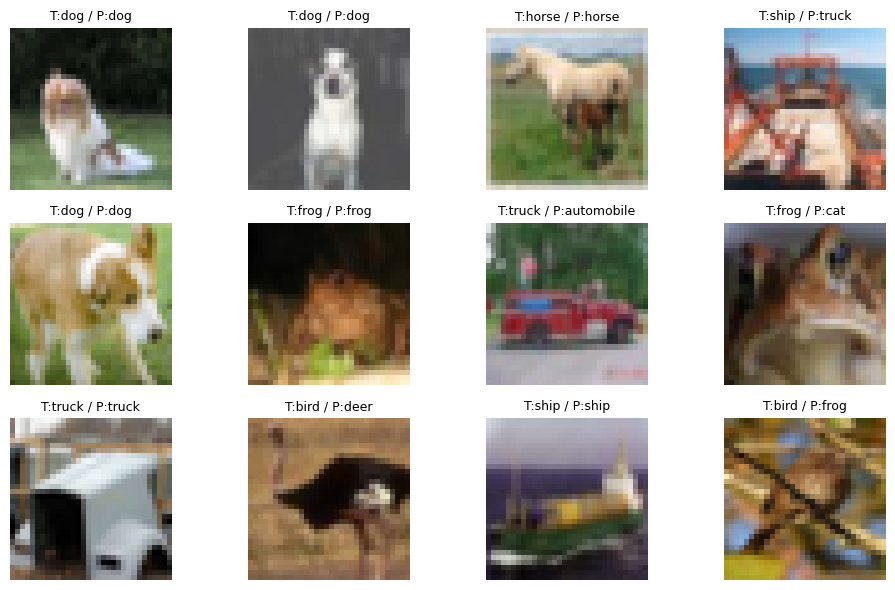

In [7]:
idx = np.random.choice(len(x_test), 12, replace=False)
imgs, ys = x_test[idx], y_test[idx]
pred = model.predict(imgs, verbose=0).argmax(axis=1)

plt.figure(figsize=(10,6))
for i, (im, ytrue, ypred) in enumerate(zip(imgs, ys, pred)):
    plt.subplot(3,4,i+1)
    plt.imshow(im)
    plt.title(f"T:{class_names[ytrue]} / P:{class_names[ypred]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()
